<span style="font-size:38px; font-weight:bold; text-align:center; display:block;">Loan Approval Prediction System</span>

---
## 📊 Dataset
https://www.kaggle.com/datasets/ssiddharth408/loan-prediction-dataset

This dataset is used to predict whether a loan application will be approved or not based on applicant details.

---

## 📌 About the Dataset

This is a **binary classification problem** where the target variable is `Loan_Status`.

The dataset contains **13 features (columns)**, and the goal is to predict the `Loan_Status` column:

- **Y → Loan Approved**  
- **N → Loan Not Approved**
---

### Importing Packages

In [235]:
!pip install -r "../requirements.txt"

### Importing Libraries

In [237]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report
import joblib

## Loading Data

In [239]:
df = pd.read_csv("../data/loan_dataset.csv")

df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


## Data Understanding

In [241]:
df.shape

(614, 13)

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             601 non-null    object 
 2   married            611 non-null    object 
 3   dependents         599 non-null    object 
 4   education          614 non-null    object 
 5   self_employed      582 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [243]:
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [244]:
df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [245]:
# df.describe(include='all')

In [246]:
# Check missing values
df.isna().sum()
# df.isnull().sum() same 

loan_id               0
gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64

---
## EDA (Exploratory Data Analysis)

### 1. Target Variable Distribution
Checking if data is balanced:

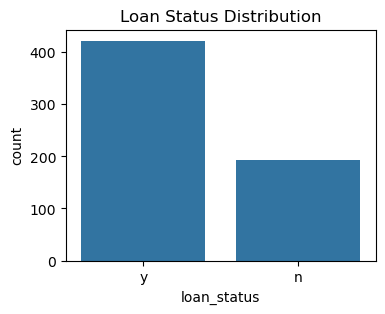

In [249]:
plt.figure(figsize=(4,3))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

#### Observation:
The dataset shows distribution of loan approvals (y) and rejections (n).  
This helps identify whether the dataset is balanced or imbalanced.

In [251]:
pd.DataFrame({
    "Count": df['loan_status'].value_counts(),
    "Percentage": df['loan_status'].value_counts(normalize=True) * 100
})

,Count,Percentage
loan_status,,
y,422,68.729642
n,192,31.270358


Target imbalance is mild → NO resampling needed

69% approved vs 31% rejected

Not severe imbalance

In [253]:
# ..other eda and stats

In [254]:
# df.corr(numeric_only=True)

---
## Data Cleaning

In [256]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [257]:
df.drop('loan_id', axis=1, inplace=True)  
# not useful so dropping it 

In [258]:
df.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [259]:
df.isnull().sum()

gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             601 non-null    object 
 1   married            611 non-null    object 
 2   dependents         599 non-null    object 
 3   education          614 non-null    object 
 4   self_employed      582 non-null    object 
 5   applicantincome    614 non-null    int64  
 6   coapplicantincome  614 non-null    float64
 7   loanamount         592 non-null    float64
 8   loan_amount_term   600 non-null    float64
 9   credit_history     564 non-null    float64
 10  property_area      614 non-null    object 
 11  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [261]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Index(['applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history'],
      dtype='object')
Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'property_area', 'loan_status'],
      dtype='object')
Number of numerical columns: 5
Number of categorical columns: 7


### Filling missing values in categorical columns using mode

In [263]:
df['gender'].mode()

0    male
Name: gender, dtype: object

In [264]:
df['gender'].mode()[0]

'male'

In [265]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
# df['gender'].fillna(df['gender'].mode()[0], inplace=True) or
df['married'].fillna(df['married'].mode()[0], inplace=True)
df['dependents'].fillna(df['dependents'].mode()[0], inplace=True)
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\1304981952.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['married'].fillna(df['married'].mode()[0], inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\1304981952.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [266]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             614 non-null    object 
 1   married            614 non-null    object 
 2   dependents         614 non-null    object 
 3   education          614 non-null    object 
 4   self_employed      614 non-null    object 
 5   applicantincome    614 non-null    int64  
 6   coapplicantincome  614 non-null    float64
 7   loanamount         592 non-null    float64
 8   loan_amount_term   600 non-null    float64
 9   credit_history     564 non-null    float64
 10  property_area      614 non-null    object 
 11  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [292]:
df.isnull().sum()

gender                0
married               0
dependents            0
education             0
self_employed         0
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64

- loanamount           22
- loan_amount_term     14
- credit_history       50 
### left that are numerical data, we will replace their null values with their respective medians :)

In [312]:
df['credit_history']

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: credit_history, Length: 614, dtype: float64

In [303]:
df['loanamount'].fillna(df['loanamount'].median(), inplace=True)
df['loan_amount_term'].fillna(df['loan_amount_term'].median(), inplace=True)


df['credit_history'].fillna(df['credit_history'].mode()[0], inplace=True) 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\2999791613.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loanamount'].fillna(df['loanamount'].median(), inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\2999791613.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [305]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             614 non-null    object 
 1   married            614 non-null    object 
 2   dependents         614 non-null    object 
 3   education          614 non-null    object 
 4   self_employed      614 non-null    object 
 5   applicantincome    614 non-null    int64  
 6   coapplicantincome  614 non-null    float64
 7   loanamount         614 non-null    float64
 8   loan_amount_term   614 non-null    float64
 9   credit_history     614 non-null    float64
 10  property_area      614 non-null    object 
 11  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [307]:
df.isnull().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
loan_status          0
dtype: int64

In [318]:
# all null values removed :)
df.isnull().values.any()

False

---
## Feature Engineering

In [321]:
df.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,male,no,0,graduate,no,5849,0.0,128.0,360.0,1.0,urban,y
1,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [329]:
df['total_income'] = df['applicantincome']+df['coapplicantincome']

df['total_income']

0      5849.0
1      6091.0
2      3000.0
3      4941.0
4      6000.0
        ...  
609    2900.0
610    4106.0
611    8312.0
612    7583.0
613    4583.0
Name: total_income, Length: 614, dtype: float64

In [331]:
df.drop('applicantincome', axis=1, inplace=True)  
df.drop('coapplicantincome', axis=1, inplace=True)
df.head()

,gender,married,dependents,education,self_employed,loanamount,loan_amount_term,credit_history,property_area,loan_status,total_income
0,male,no,0,graduate,no,128.0,360.0,1.0,urban,y,5849.0
1,male,yes,1,graduate,no,128.0,360.0,1.0,rural,n,6091.0
2,male,yes,0,graduate,yes,66.0,360.0,1.0,urban,y,3000.0
3,male,yes,0,not graduate,no,120.0,360.0,1.0,urban,y,4941.0
4,male,no,0,graduate,no,141.0,360.0,1.0,urban,y,6000.0


In [346]:
df.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'loanamount', 'loan_amount_term', 'credit_history', 'property_area',
       'loan_status', 'total_income'],
      dtype='object')

In [366]:
print(
df['gender'].unique(),"\n",

df['married'].unique(),"\n",

df['education'].unique(),"\n",

df['self_employed'].unique(),"\n",

df['property_area'].unique(),"\n",

df['loan_status'].unique())

['male' 'female'] 
 ['no' 'yes'] 
 ['graduate' 'not graduate'] 
 ['no' 'yes'] 
 ['urban' 'rural' 'semiurban'] 
 ['y' 'n']


In [368]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [370]:
df.head()

,gender,married,dependents,education,self_employed,loanamount,loan_amount_term,credit_history,property_area,loan_status,total_income
0,1,no,0,graduate,no,128.0,360.0,1.0,urban,y,5849.0
1,1,yes,1,graduate,no,128.0,360.0,1.0,rural,n,6091.0
2,1,yes,0,graduate,yes,66.0,360.0,1.0,urban,y,3000.0
3,1,yes,0,not graduate,no,120.0,360.0,1.0,urban,y,4941.0
4,1,no,0,graduate,no,141.0,360.0,1.0,urban,y,6000.0


In [372]:
df['married'] = df['married'].replace({'yes': 1, 'no': 0})
df['education'] = df['education'].replace({'graduate': 1, 'not graduate': 0})
df['self_employed'] = df['self_employed'].replace({'yes': 1, 'no': 0})
df['property_area'] = df['property_area'].replace({'urban': 0, 'rural': 1, 'semiurban':2})
df['loan_status'] = df['loan_status'].replace({'n': 0, 'y': 1})


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\3783674339.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['married'] = df['married'].replace({'yes': 1, 'no': 0})
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\3783674339.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['education'] = df['education'].replace({'graduate': 1, 'not graduate': 0})
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3728\3783674339.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

In [374]:
df

,gender,married,dependents,education,self_employed,loanamount,loan_amount_term,credit_history,property_area,loan_status,total_income
0,1,0,0,1,0,128.0,360.0,1.0,0,1,5849.0
1,1,1,1,1,0,128.0,360.0,1.0,1,0,6091.0
2,1,1,0,1,1,66.0,360.0,1.0,0,1,3000.0
3,1,1,0,0,0,120.0,360.0,1.0,0,1,4941.0
4,1,0,0,1,0,141.0,360.0,1.0,0,1,6000.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,71.0,360.0,1.0,1,1,2900.0
610,1,1,3+,1,0,40.0,180.0,1.0,1,1,4106.0
611,1,1,1,1,0,253.0,360.0,1.0,0,1,8312.0
612,1,1,2,1,0,187.0,360.0,1.0,0,1,7583.0


In [ ]:
# Data All cleaned ad 